In [12]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [13]:
#assuming factor's datasets can be approximated to a normal distribution, and thus can be standardised,
#function to standardise factors later
def standardise(factor):
    return (factor - factor.mean())/factor.std()

In [ ]:
#get data and returns
tickers = ["PLY.AX", "LAU.AX", "TLX.AX", "COS.AX", "ANG.AX", "VVA.AX", "WTC.AX", "AUB.AX", "XYZ.AX", "DUG.AX"]
data = yf.download(tickers, start ="2024-01-01", end = "2025-12-31")
returns = data["Close"].pct_change().dropna()

[*********************100%***********************]  10 of 10 completed


In [ ]:
#to calculate the 5 factors:
# 1. Momentum factor 60-day rolling sum
momentum = returns.rolling(60).sum()

# 2. Volatility factor 60-day rolling std
volatility = returns.rolling(60).std()

# 3. Liquidity factor - dollar value traded, using volume * price
liquidity = data["Volume"] * data["Close"]
liquidity = liquidity.rolling(60).mean() #60-day rolling average of dollar value traded bc daily less reliable

# 4. Value factor - P/E, P/B (got rid of PEG because its missing for most stocks so make aligning final dataframe hard due to n/a values)
pe = {}
pb = {}

for t in tickers:
    stock = yf.Ticker(t)
    info = stock.info
    pe_val = info.get("trailingPE")
    if pe_val is not None:
        pe[t] = float(pe_val) 
    else: pe[t] = None    
    pb_val = info.get("priceToBook")
    if pb_val is not None:
        pb[t] = float(pb_val)
    else:   pb[t] = None
     #value_factor = (pe + pb + peg)/3 - if combo works  not sure if conbining them is best
value_df = pd.DataFrame({
    "PE": pe,
    "PB": pb
})

#convert to value signals, as higher PE, PB, PEG indicate lower value, so take inverse
value_df["Earnings_Yield"] = 1 / value_df["PE"]
value_df["Book_to_Market"] = 1 / value_df["PB"]
#clean value_df by replacing inf with None and for rows with na values, assume neutral exposure so replace with mean
value_df = value_df.replace([float("inf"), -float("inf")], None)
value_df = value_df.fillna(value_df.mean())
#combine to one value factor
valcombined = value_df[["Earnings_Yield", "Book_to_Market"]].mean(axis=1)
#expand across time points to align with other factors for regression
value = pd.DataFrame(
    [valcombined.values] * len(momentum.index),
    index=momentum.index,
    columns=momentum.columns
)

#5. industry factor - binary variable for industry classification, using yfinance's sector info
industry_map = {
    "PLY.AX": "Industrials",
    "LAU.AX": "Industrials",
    "TLX.AX": "Healthcare",
    "COS.AX": "Industrials",
    "ANG.AX": "Energy",
    "VVA.AX": "Financials",
    "WTC.AX": "Tech",
    "AUB.AX": "Financials",
    "XYZ.AX": "Materials",
    "DUG.AX": "Energy"
}
industry_df = pd.DataFrame.from_dict(
    industry_map, orient="index", columns=["industry"]
)
industry_df = industry_df.loc[returns.columns]
industry_bin = pd.get_dummies(industry_df["industry"])
industry_bin = industry_bin.iloc[:, :-1]
industry_bin = industry_bin.astype(int)
industry_expanded = pd.concat(
    [industry_bin] * len(returns),
    keys=returns.index
)
industry_expanded.index.names = ["Date", "Stock"]


In [ ]:
#combining factors into one dataframe for regression and formatting for alignment
#Standardise the factors into z scores (1 to 4)
momentum_z = standardise(momentum)
volatility_z= standardise(volatility)
liquidity_z = standardise(liquidity)
value_z = standardise(value)
print(momentum_z.shape)
print(volatility_z.shape)
print(liquidity_z.shape)
print(value_z.shape)

commindex = momentum_z.index
momentum_z = momentum_z.loc[commindex]
volatility_z = volatility_z.loc[commindex]
liquidity_z = liquidity_z.loc[commindex]
value_z = value_z.loc[commindex]

#combine everything
factors = pd.concat({
    "momentum": momentum_z,
    "volatility": volatility_z,
    "liquidity": liquidity_z,
    "value": value_z
}, axis=1)
factors = factors.sort_index()
#check
print(factors.head(100))

(244, 10)
(244, 10)
(506, 10)
(244, 10)
            momentum                                                    \
Ticker        ANG.AX    AUB.AX    COS.AX    DUG.AX    LAU.AX    PLY.AX   
Date                                                                     
2025-01-14       NaN       NaN       NaN       NaN       NaN       NaN   
2025-01-15       NaN       NaN       NaN       NaN       NaN       NaN   
2025-01-16       NaN       NaN       NaN       NaN       NaN       NaN   
2025-01-17       NaN       NaN       NaN       NaN       NaN       NaN   
2025-01-20       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2025-06-02  1.302287  1.072525  0.175613 -0.413864  1.860457 -1.268856   
2025-06-03  1.313770  1.213498  0.212275 -0.666509  1.927020 -1.303960   
2025-06-04  1.194763  1.527822  0.107742 -0.567770  0.623074 -1.452856   
2025-06-05  1.302569  1.275633 -0.519992 -0.493111  0.942020 -1.376593  

# Cross sectional regression to get factor returns
- rt = B_t * f_t + e_t, solving for f_t using OLS regression for each time point
- assume f_t is what we are trying to find which are factor exposures, four values for each factor
- output will be visualized data with heatmaps and graphsshowing factor correlation, r squared, idiosyncratic correlation, as well as final dataframe with wanted values

Factor Returns:


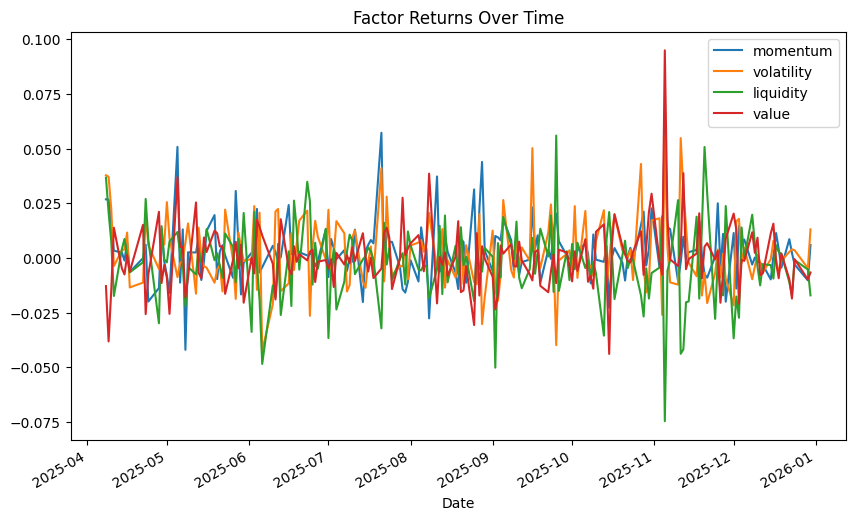

Factor Volatility:


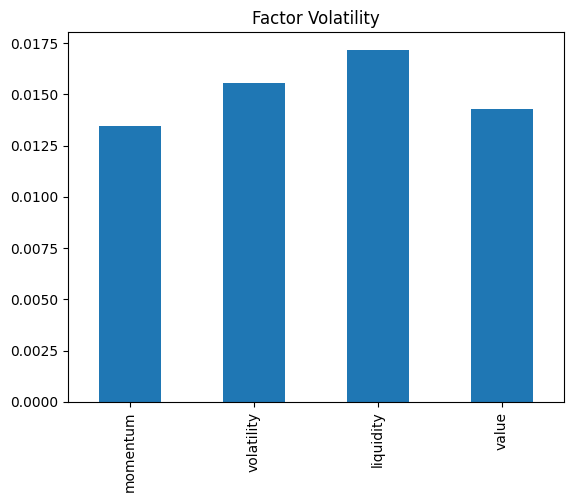

Idiosyncratic Volatility:


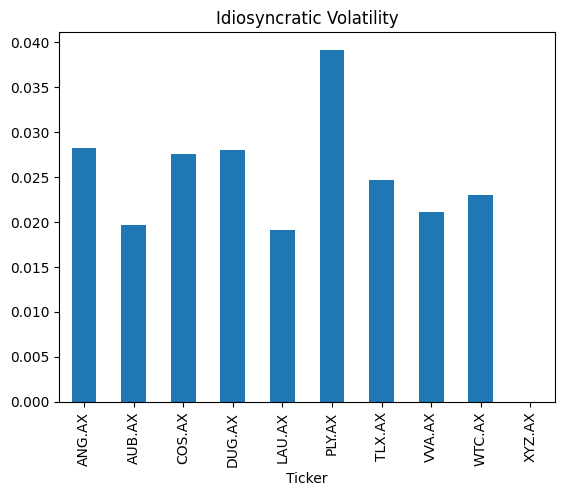

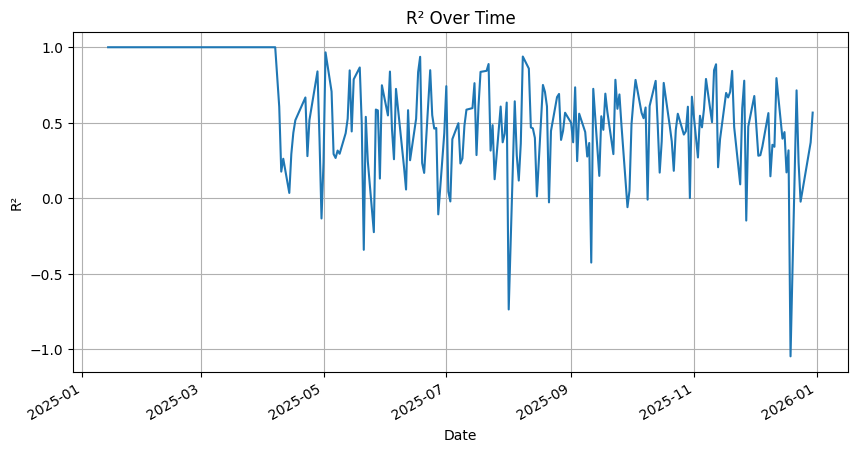

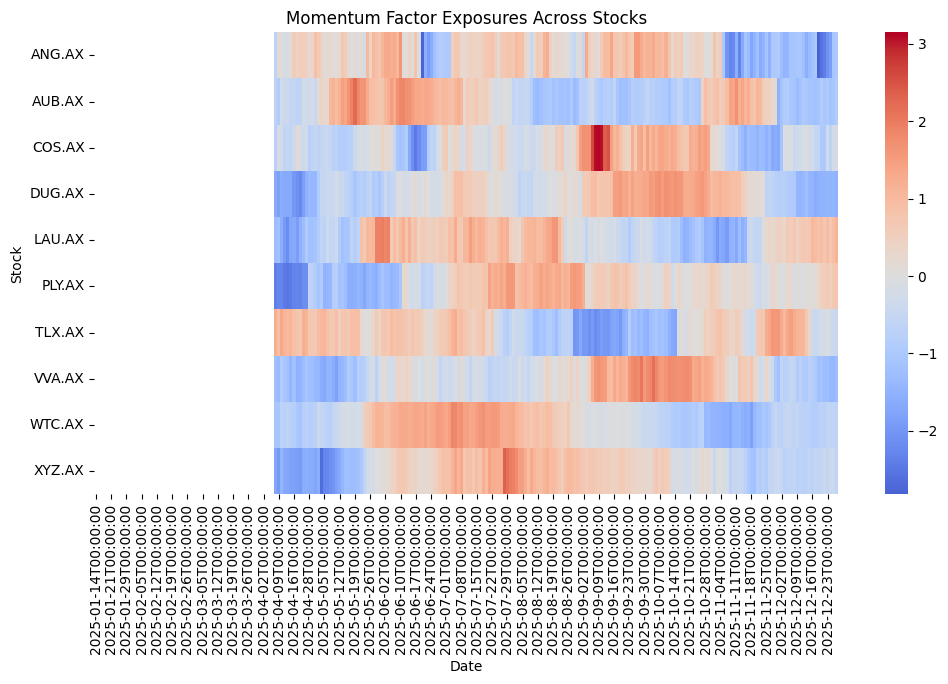

Correlation between factors:


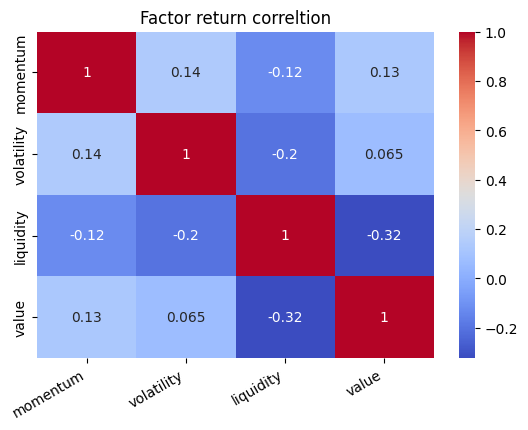

Final DataFrame:
            Factor_Returns  Factor_Volatility  Idiosyncratic_Volatility  \
ANG.AX                 NaN                NaN                  0.028202   
AUB.AX                 NaN                NaN                  0.019635   
COS.AX                 NaN                NaN                  0.027513   
DUG.AX                 NaN                NaN                  0.028012   
LAU.AX                 NaN                NaN                  0.019139   
PLY.AX                 NaN                NaN                  0.039136   
TLX.AX                 NaN                NaN                  0.024617   
VVA.AX                 NaN                NaN                  0.021103   
WTC.AX                 NaN                NaN                  0.023016   
XYZ.AX                 NaN                NaN                       NaN   
liquidity        -0.002140           0.017175                       NaN   
momentum          0.003158           0.013437                       NaN   
value   

In [69]:
from time import time
import seaborn as sns
factor_returns = []

# reshape factor exposures so each row is one stock-date observation
exposure = factors.stack(level=1)
exposure.index.names = ["Date", "Ticker"]
for date in returns.index:
    r = returns.loc[date]
    b = exposure.loc[date]
    df = pd.concat([r, b], axis=1, join="inner").dropna()
    if df.empty:
        factor_returns.append(np.full(b.shape[1], np.nan))
        continue
    y = df.iloc[:, 0].values
    B = df.iloc[:, 1:].values
    f = np.linalg.lstsq(B, y, rcond=None)[0]
    factor_returns.append(f)

factor_returns = pd.DataFrame(factor_returns, index=returns.index, columns=b.columns)

idiosyncratic = []
for date in returns.index:
    r = returns.loc[date]
    B = exposure.loc[date].dropna()
    if B.empty:
        idiosyncratic.append(np.full(len(r), np.nan))
        continue

    f = factor_returns.loc[date]
    aligned_r = r.loc[B.index]
    eps = aligned_r.values - B.values @ f.values
    idiosyncratic.append(eps)

idiosyncratic_df = pd.DataFrame(idiosyncratic, index=returns.index, columns=returns.columns)
factor_vols = factor_returns.std()
idiosyncratic_vols = idiosyncratic_df.std()

#Cross sectional R2 per day
R2 = []
for date in returns.index:
    r = returns.loc[date]
    eps = idiosyncratic_df.loc[date]
    total_var = ((r - r.mean())**2).sum()      
    residual_var = (eps**2).sum()               
    r2 = 1 - residual_var / total_var
    R2.append(r2)
R2 = pd.Series(R2, index=returns.index)

# Visualisation:
print("Factor Returns:")
factor_returns.plot(figsize=(10,6), title="Factor Returns Over Time")
plt.show()
print("Factor Volatility:")
factor_vols.plot(kind="bar", title="Factor Volatility")
plt.show()
print("Idiosyncratic Volatility:")
idiosyncratic_vols.plot(kind="bar", title="Idiosyncratic Volatility")
plt.show()

#R2 over time map:
plt.figure(figsize=(10,5))
R2.plot(title="R² Over Time")
plt.ylabel("R²")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# momentum factor exposures heatmap
plt.figure(figsize=(12,6))
sns.heatmap(factors.xs("momentum", axis=1, level=0).T, cmap="coolwarm", center=0)
plt.title("Momentum Factor Exposures Across Stocks")
plt.ylabel("Stock")
plt.xlabel("Date")
plt.show()

#correlation between factors heatmap:
print("Correlation between factors:")
R2.plot(title = "Factor return correltion")
factor_returns.corr()
sns.heatmap(factor_returns.corr(), annot=True, cmap="coolwarm")
plt.show()

#final dataframe of factor returns, factor volatility, idiosyncratic volatility, R2, and correlation between factors:
final_df = pd.DataFrame({
    "Factor_Returns": factor_returns.mean(),
    "Factor_Volatility": factor_vols,
    "Idiosyncratic_Volatility": idiosyncratic_vols,
    "R2": R2.mean()
})
print("Final DataFrame:")
print(final_df)